In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('final_normal_data.csv')

In [3]:
df.drop('Unnamed: 0',axis=1,inplace=True)

In [4]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'emp_length',
       'home_ownership', 'annual_inc', 'verification_status', 'dti',
       'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'revol_util', 'total_acc',
       'loan_status', 'fico_score'],
      dtype='object')

In [8]:
df.shape

(1345310, 17)

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop("loan_status", axis=1)
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1076248, 16)
(269062, 16)


In [7]:
from imblearn.over_sampling import SMOTE

# Keep imbalance realistic (do NOT use 1.0 immediately)
smote = SMOTE(
    sampling_strategy=0.6,   # minority will be 60% of majority
    random_state=42
)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print("X_train_sm shape:", X_train_sm.shape)
print("y_train_sm value counts:\n", y_train_sm.value_counts())

After SMOTE:
X_train_sm shape: (1378241, 16)
y_train_sm value counts:
 loan_status
0    861401
1    516840
Name: count, dtype: int64


In [9]:


sample_size = 250000

X_train_sample = X_train_sm.sample(n=sample_size, random_state=42)
y_train_sample = y_train_sm.loc[X_train_sample.index]

In [10]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42
)

param_grid = {
    "n_estimators": [300,400,500],
    "max_depth": [4,5,6,7],
    "learning_rate": [0.03,0.05,0.07],
    "subsample": [0.7,0.8,1],
    "colsample_bytree": [0.7,0.8,1],
    "scale_pos_weight": [2,3,4]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=15,
    scoring='recall',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

In [11]:
random_search.fit(X_train_sample, y_train_sample)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1],
                                        'learning_rate': [0.03, 0.05, 0.07],
                                        'max_depth': [4, 5, 6, 7],
                                        'n_estimators': [300, 400, 500],
                                        'scale_pos_weight': [2, 3, 4],
                                        'subsample': [0.7, 0.8, 1]},
                   random_state=42, scoring='recall', verbose=2)

In [25]:
best_params

{'subsample': 0.8,
 'scale_pos_weight': 4,
 'n_estimators': 400,
 'max_depth': 6,
 'learning_rate': 0.03,
 'colsample_bytree': 0.7}

{'subsample': 0.8,
 'scale_pos_weight': 4,
 'n_estimators': 400,
 'max_depth': 6,
 'learning_rate': 0.03,
 'colsample_bytree': 0.7}

In [12]:
best_params = random_search.best_params_

final_model = XGBClassifier(**best_params)

final_model.fit(X_train_sm, y_train_sm)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=None, num_parallel_tree=None, ...)

In [14]:
from sklearn.metrics import classification_report, roc_auc_score
pred = final_model.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.89      0.57      0.69    215350
           1       0.30      0.73      0.42     53712

    accuracy                           0.60    269062
   macro avg       0.60      0.65      0.56    269062
weighted avg       0.78      0.60      0.64    269062



In [15]:
from sklearn.metrics import classification_report
import numpy as np

probs = final_model.predict_proba(X_test)[:,1]

for t in np.arange(0.4, 0.7, 0.05):

    print(f"\nThreshold = {t:.2f}")
    preds = (probs >= t).astype(int)
    print(classification_report(y_test, preds))


Threshold = 0.40
              precision    recall  f1-score   support

           0       0.92      0.37      0.53    215350
           1       0.26      0.87      0.40     53712

    accuracy                           0.47    269062
   macro avg       0.59      0.62      0.47    269062
weighted avg       0.79      0.47      0.51    269062


Threshold = 0.45
              precision    recall  f1-score   support

           0       0.91      0.47      0.62    215350
           1       0.28      0.81      0.41     53712

    accuracy                           0.54    269062
   macro avg       0.59      0.64      0.52    269062
weighted avg       0.78      0.54      0.58    269062


Threshold = 0.50
              precision    recall  f1-score   support

           0       0.89      0.57      0.69    215350
           1       0.30      0.73      0.42     53712

    accuracy                           0.60    269062
   macro avg       0.60      0.65      0.56    269062
weighted avg       0

Compute PR-AUC (better metric for imbalance)

Plot Precision-Recall curve

Do cost-based evaluation (banking style)

In [16]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, probs)

print("PR-AUC:", pr_auc)

PR-AUC: 0.3715041704675056


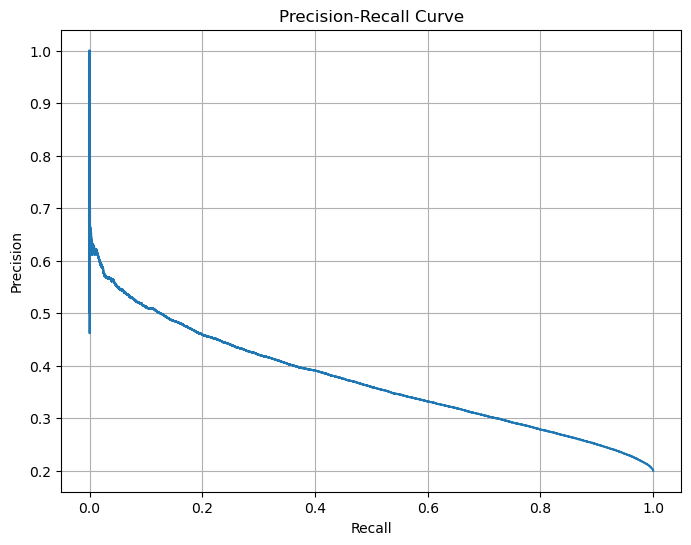

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, probs)

plt.figure(figsize=(8,6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

In [18]:
from sklearn.metrics import confusion_matrix

threshold = 0.55
preds = (probs >= threshold).astype(int)

cm = confusion_matrix(y_test, preds)

tn, fp, fn, tp = cm.ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

TN: 142504
FP: 72846
FN: 19255
TP: 34457


In [19]:
for t in np.arange(0.4, 0.7, 0.05):

    preds = (probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

    total_cost = (fn * 100000) + (fp * 10000)

    print(f"\nThreshold {t:.2f}")
    print("FN:", fn, "FP:", fp)
    print("Total Cost:", total_cost)


Threshold 0.40
FN: 6828 FP: 134691
Total Cost: 2029710000

Threshold 0.45
FN: 10188 FP: 114318
Total Cost: 2161980000

Threshold 0.50
FN: 14357 FP: 93296
Total Cost: 2368660000

Threshold 0.55
FN: 19255 FP: 72846
Total Cost: 2653960000

Threshold 0.60
FN: 24984 FP: 53635
Total Cost: 3034750000

Threshold 0.65
FN: 31173 FP: 36065
Total Cost: 3477950000


## Build Lift chart

In [20]:
import pandas as pd
import numpy as np

# Create evaluation dataframe
eval_df = pd.DataFrame({
    "y_true": y_test,
    "prob": probs
})

# Sort by highest risk first
eval_df = eval_df.sort_values("prob", ascending=False).reset_index(drop=True)

In [21]:
eval_df["decile"] = pd.qcut(
    eval_df.index,
    10,
    labels=False
) + 1

In [22]:
gain_table = eval_df.groupby("decile").agg(
    total_customers=("y_true", "count"),
    total_defaults=("y_true", "sum")
).reset_index()

# Sort properly (1 = highest risk)
gain_table = gain_table.sort_values("decile")

# Cumulative calculations
gain_table["cum_defaults"] = gain_table["total_defaults"].cumsum()
gain_table["cum_customers"] = gain_table["total_customers"].cumsum()

total_defaults = gain_table["total_defaults"].sum()

gain_table["gain_%"] = gain_table["cum_defaults"] / total_defaults * 100
gain_table["population_%"] = gain_table["cum_customers"] / len(eval_df) * 100

gain_table

,decile,total_customers,total_defaults,cum_defaults,cum_customers,gain_%,population_%
0,1,26907,12105,12105,26907,22.536863,10.000297
1,2,26906,8983,21088,53813,39.261245,20.000223
2,3,26906,7273,28361,80719,52.801981,30.000149
3,4,26906,6180,34541,107625,64.307790,40.000074
4,5,26906,5139,39680,134531,73.875484,50.000000
5,6,26906,4388,44068,161437,82.044981,59.999926
6,7,26906,3671,47739,188343,88.879580,69.999851
7,8,26906,2875,50614,215249,94.232201,79.999777
8,9,26906,2009,52623,242155,97.972520,89.999703
9,10,26907,1089,53712,269062,100.000000,100.000000


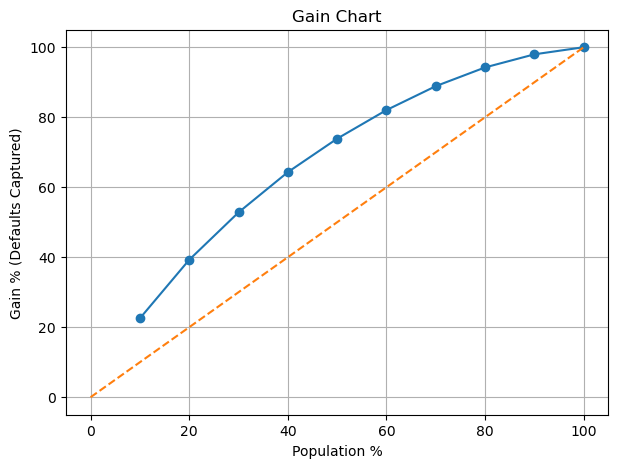

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(gain_table["population_%"], gain_table["gain_%"], marker="o")
plt.plot([0,100], [0,100], linestyle="--")  # random model line
plt.xlabel("Population %")
plt.ylabel("Gain % (Defaults Captured)")
plt.title("Gain Chart")
plt.grid()
plt.show()

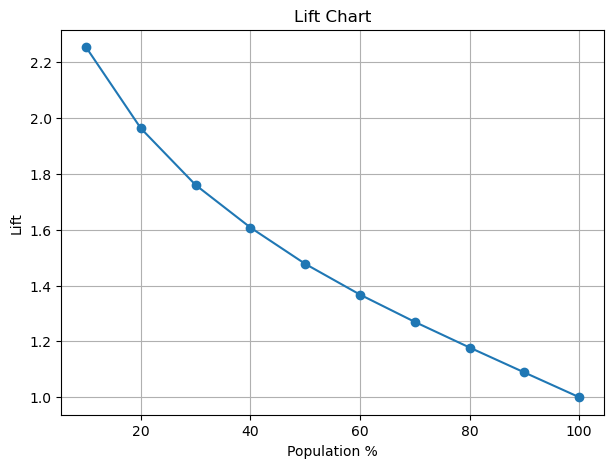

In [24]:
gain_table["lift"] = gain_table["gain_%"] / gain_table["population_%"]

plt.figure(figsize=(7,5))
plt.plot(gain_table["population_%"], gain_table["lift"], marker="o")
plt.xlabel("Population %")
plt.ylabel("Lift")
plt.title("Lift Chart")
plt.grid()
plt.show()

## KS-STATISTICS

In [26]:
# Create evaluation dataframe
ks_df = pd.DataFrame({
    "y_true": y_test,
    "prob": probs
})

# Sort by risk descending
ks_df = ks_df.sort_values("prob", ascending=False).reset_index(drop=True)

# Create deciles
ks_df["decile"] = pd.qcut(ks_df.index, 10, labels=False) + 1

# Group by decile
ks_table = ks_df.groupby("decile").agg(
    total=("y_true", "count"),
    defaults=("y_true", "sum")
).reset_index()

ks_table["non_defaults"] = ks_table["total"] - ks_table["defaults"]

# Totals
total_defaults = ks_table["defaults"].sum()
total_non_defaults = ks_table["non_defaults"].sum()

# Cumulative %
ks_table["cum_defaults_%"] = ks_table["defaults"].cumsum() / total_defaults * 100
ks_table["cum_non_defaults_%"] = ks_table["non_defaults"].cumsum() / total_non_defaults * 100

# KS value
ks_table["KS"] = abs(ks_table["cum_defaults_%"] - ks_table["cum_non_defaults_%"])

ks_table

,decile,total,defaults,non_defaults,cum_defaults_%,cum_non_defaults_%,KS
0,1,26907,12105,14802,22.536863,6.873462,15.663401
1,2,26906,8983,17923,39.261245,15.196192,24.065053
2,3,26906,7273,19633,52.801981,24.312979,28.489002
3,4,26906,6180,20726,64.307790,33.937311,30.370478
4,5,26906,5139,21767,73.875484,44.045043,29.830441
5,6,26906,4388,22518,82.044981,54.501509,27.543471
6,7,26906,3671,23235,88.879580,65.290922,23.588658
7,8,26906,2875,24031,94.232201,76.449965,17.782236
8,9,26906,2009,24897,97.972520,88.011145,9.961375
9,10,26907,1089,25818,100.000000,100.000000,0.000000


In [27]:
ks_value = ks_table["KS"].max()
print("KS Statistic:", ks_value)

KS Statistic: 30.370478339568038


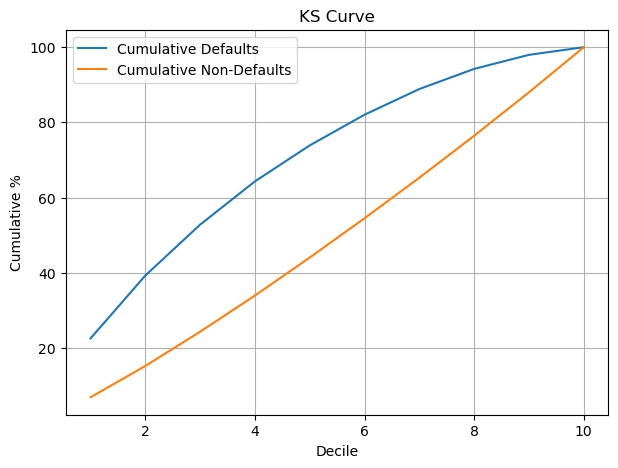

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(ks_table["decile"], ks_table["cum_defaults_%"], label="Cumulative Defaults")
plt.plot(ks_table["decile"], ks_table["cum_non_defaults_%"], label="Cumulative Non-Defaults")
plt.xlabel("Decile")
plt.ylabel("Cumulative %")
plt.title("KS Curve")
plt.legend()
plt.grid()
plt.show()

In [29]:
risk_df = pd.DataFrame({
    "prob": probs,
    "y_true": y_test
})

risk_df["risk_band"] = pd.qcut(
    risk_df["prob"],
    q=[0, 0.3, 0.7, 1.0],
    labels=["Low", "Medium", "High"]
)

risk_df.head()

,prob,y_true,risk_band
1311262,0.316295,0,Low
823606,0.435762,0,Medium
196043,0.273423,0,Low
810959,0.503865,0,Medium
1157129,0.663488,0,High


In [30]:
risk_summary = risk_df.groupby("risk_band").agg(
    customers=("y_true", "count"),
    defaults=("y_true", "sum")
).reset_index()

risk_summary["default_rate_%"] = (
    risk_summary["defaults"] / risk_summary["customers"] * 100
)

risk_summary

C:\Users\cheen\AppData\Local\Temp\ipykernel_11100\2022953687.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_summary = risk_df.groupby("risk_band").agg(


,risk_band,customers,defaults,default_rate_%
0,Low,80719,5973,7.399745
1,Medium,107624,19378,18.005278
2,High,80719,28361,35.135470
